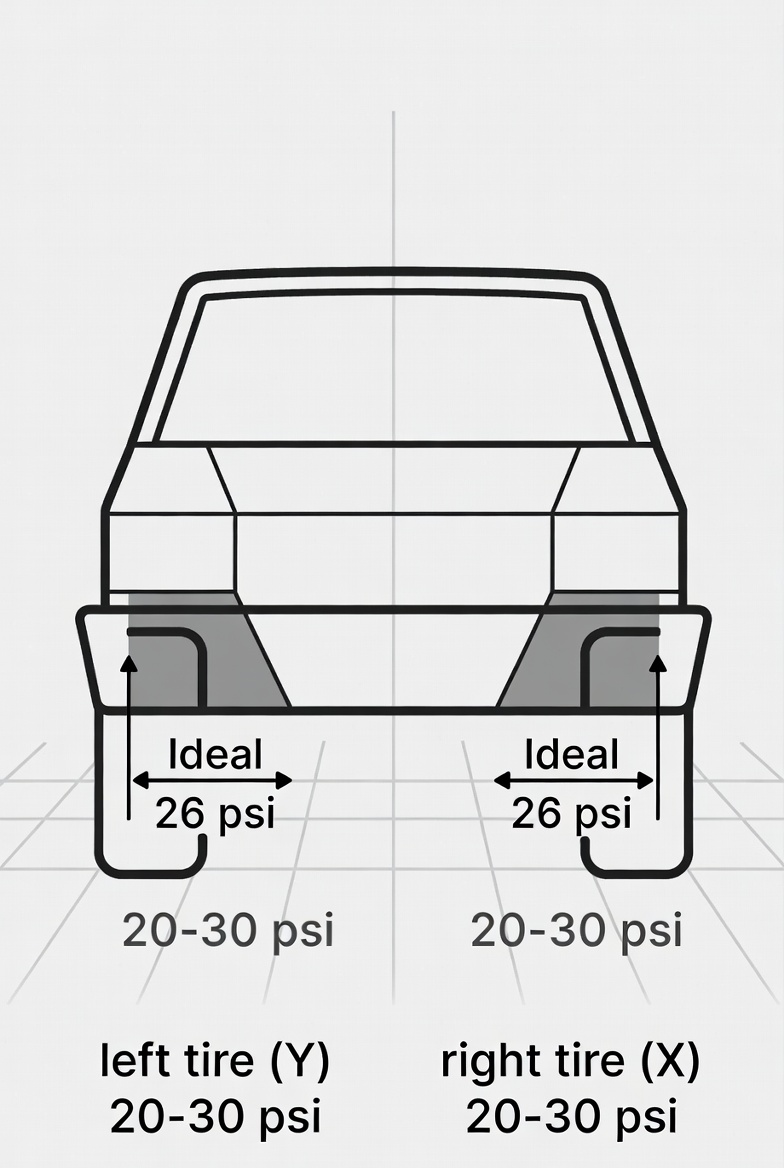

FormBox["7.894736842105263`*^-6", TraditionalForm]
  3
------
380000
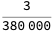

In [7]:
K = N[3/380000] //TraditionalForm
K = 3/380000

In [10]:
f[x_,y_]:=K*(x^2+y^2)

In [12]:
Integrate[f[x,y],{x,20,26},{y,20,26}]//N

0.3024

-Graphics-
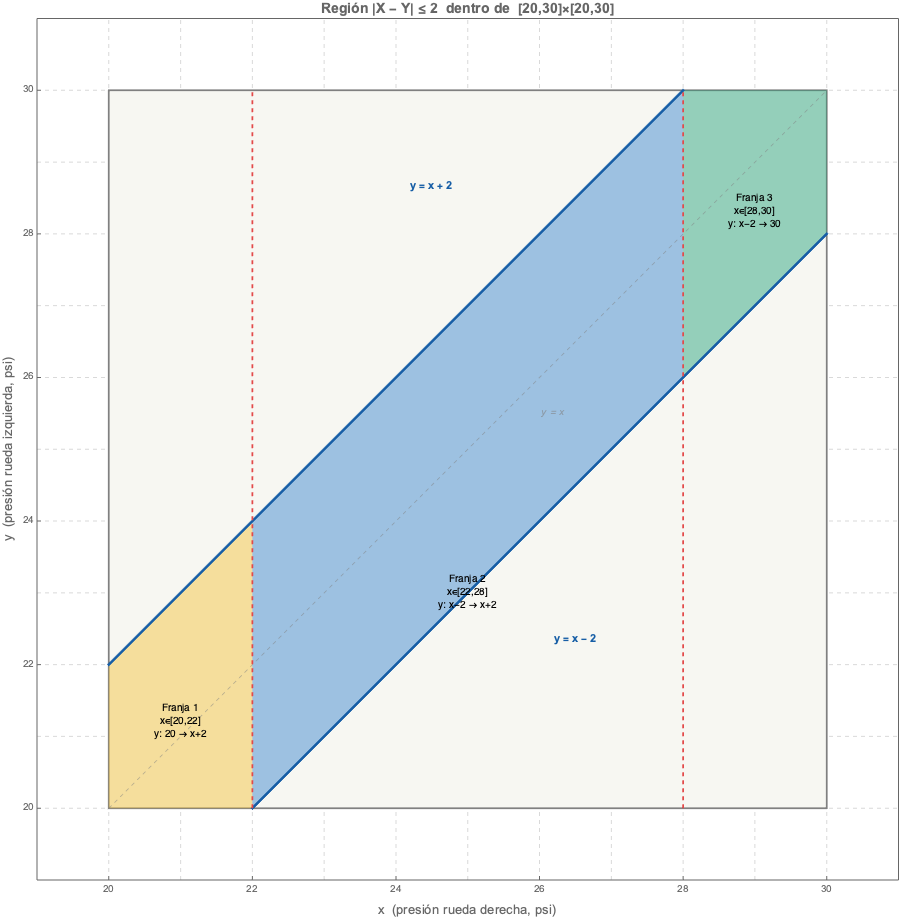

In [148]:
(* ============================================================
   Calibreme el aire — Ítem (c)
   Región de integración: P(|X - Y| <= 2)
   sobre el cuadrado [20,30] x [20,30]
   ============================================================ *)

(* --- Colores --- *)
colorBanda   = RGBColor[0.18, 0.50, 0.80, 0.30];  (* azul translúcido *)
colorFranja1 = RGBColor[0.95, 0.75, 0.20, 0.45];  (* ámbar *)
colorFranja2 = RGBColor[0.18, 0.50, 0.80, 0.45];  (* azul *)
colorFranja3 = RGBColor[0.11, 0.62, 0.46, 0.45];  (* verde teal *)
colorLinea   = RGBColor[0.09, 0.37, 0.65];         (* azul oscuro *)
colorDivider = RGBColor[0.89, 0.29, 0.29];         (* rojo *)

(* --- Región completa de la banda (polígono) --- *)
bandaPoligono = Polygon[{
  {20, 20}, {22, 20},   (* borde inferior *)
  {30, 28},             (* esquina y = x-2 en x=30 *)
  {30, 30}, {28, 30},   (* esquina superior derecha *)
  {20, 22}              (* y = x+2 en x=20 *)
}];

(* --- Tres franjas de integración --- *)
franja1 = Polygon[{
  {20, 20}, {22, 20}, {22, 24}, {20, 22}
}];

franja2 = Polygon[{
  {22, 20}, {28, 20},   (* NO: límites reales son y=x-2 a y=x+2 *)
  (* Usamos los vértices correctos de la banda entre x=22 y x=28 *)
  {22, 20}, {28, 26}, {28, 30}, {22, 24}
}];
(* Corrijo franja2: vértices de la banda para x in [22,28] *)
franja2 = Polygon[{
  {22, 20},   (* x=22, y=x-2=20 *)
  {28, 26},   (* x=28, y=x-2=26 *)
  {28, 30},   (* x=28, y=x+2=30 *)
  {22, 24}    (* x=22, y=x+2=24 *)
}];

franja3 = Polygon[{
  {28, 26},   (* x=28, y=x-2=26 *)
  {30, 28},   (* x=30, y=x-2=28 *)
  {30, 30},   (* x=30, y=30 (tope) *)
  {28, 30}    (* x=28, y=30 (tope) *)
}];

(* --- Gráfico principal --- *)
grafico = Graphics[{

  (* Cuadrado de soporte [20,30]x[20,30] *)
  EdgeForm[{Gray, Thickness[0.002]}],
  FaceForm[RGBColor[0.97, 0.97, 0.95]],
  Rectangle[{20, 20}, {30, 30}],

  (* Franjas coloreadas *)
  EdgeForm[None],
  FaceForm[colorFranja1], franja1,
  FaceForm[colorFranja2], franja2,
  FaceForm[colorFranja3], franja3,

  (* Diagonal de referencia y = x *)
  {Dashed, Gray, Opacity[0.5], Thickness[0.001],
   Line[{{20, 20}, {30, 30}}]},

  (* Líneas de la banda y = x+2 e y = x-2 *)
  {colorLinea, Thickness[0.003],
   Line[{{20, 22}, {28, 30}}]},   (* y = x + 2 *)
  {colorLinea, Thickness[0.003],
   Line[{{22, 20}, {30, 28}}]},   (* y = x - 2 *)

  (* Divisores verticales x=22 y x=28 *)
  {colorDivider, Dashed, Thickness[0.002],
   Line[{{22, 20}, {22, 30}}]},
  {colorDivider, Dashed, Thickness[0.002],
   Line[{{28, 20}, {28, 30}}]},

  (* Etiquetas de las líneas de la banda *)
  {colorLinea,
   Text[Style["y = x + 2", 11, Bold, colorLinea],
        {24.5, 28.5}, {0, -1.5}],
   Text[Style["y = x \[Minus] 2", 11, Bold, colorLinea],
        {26.5, 22.5}, {0, 1.5}]},

  (* Etiqueta y = x *)
  {Gray, Opacity[0.6],
   Text[Style["y = x", 10, Italic, Gray], {26, 25.5}, {-1.2, 0}]},

  (* Etiquetas de franjas *)
  {Black,
   Text[Style["Franja 1\nx\[Element][20,22]\ny: 20 \[Rule] x+2",
              10, FontFamily -> "Helvetica"],
        {21, 21.2}, {0, 0}],
   Text[Style["Franja 2\nx\[Element][22,28]\ny: x\[Minus]2 \[Rule] x+2",
              10, FontFamily -> "Helvetica"],
        {25, 23}, {0, 0}],
   Text[Style["Franja 3\nx\[Element][28,30]\ny: x\[Minus]2 \[Rule] 30",
              10, FontFamily -> "Helvetica"],
        {29, 28.3}, {0, 0}]}

}, AspectRatio -> 1,
   Frame -> True,
   FrameLabel -> {
     Style["x  (presión rueda derecha, psi)", 13],
     Style["y  (presión rueda izquierda, psi)", 13]
   },
   FrameTicks -> {
     {Table[i, {i, 20, 30, 2}], None},
     {Table[i, {i, 20, 30, 2}], None}
   },
   PlotRange -> {{19, 31}, {19, 31}},
   GridLines -> {Table[i, {i, 20, 30}], Table[i, {i, 20, 30}]},
   GridLinesStyle -> Directive[LightGray, Dashed, Thickness[0.0005]],
   PlotLabel -> Style[
     "Región |X \[Minus] Y| \[LessEqual] 2  dentro de  [20,30]\[Times][20,30]",
     14, Bold],
   ImageSize -> 900,
   Background -> White
];


(* --- Mostrar el gráfico --- *)
grafico


In [73]:
(* ============================================================
   Calibreme el aire — Ítem (c)
   Integral completa: P(|X - Y| <= 2)
   ============================================================ *)

(* Valor de K obtenido en el ítem (a) *)
K = 3/380000;

(* Función de densidad conjunta *)
f[x_, y_] := K * (x^2 + y^2);

(* --- Las tres integrales según las franjas --- *)

(* Franja 1: x in [20,22], y de 20 a x+2 (línea y=x-2 queda bajo el cuadrado) *)
I1 = Integrate[Integrate[f[x, y], {y, 20, x + 2}], {x, 20, 22}];

(* Franja 2: x in [22,28], y de x-2 a x+2 (banda completa dentro del cuadrado) *)
I2 = Integrate[Integrate[f[x, y], {y, x - 2, x + 2}], {x, 22, 28}];

(* Franja 3: x in [28,30], y de x-2 a 30 (línea y=x+2 supera el cuadrado) *)
I3 = Integrate[Integrate[f[x, y], {y, x - 2, 30}], {x, 28, 30}];

(* --- Resultado final --- *)
prob = I1 + I2 + I3;

(* --- Salida --- *)
Print["I1 = ", I1, "  \[TildeTilde]  ", N[I1, 6]];
Print["I2 = ", I2, "  \[TildeTilde]  ", N[I2, 6]];
Print["I3 = ", I3, "  \[TildeTilde]  ", N[I3, 6]];
Print[""];
Print["P(|X - Y| \[LessEqual] 2)  =  I1 + I2 + I3  =  ", prob,
      "  \[TildeTilde]  ", N[prob, 6]];


     2051
I1 = -----  ~~  0.0431789
     47500
     2829
I2 = -----  ~~  0.238232
     11875
     3701
I3 = -----  ~~  0.0779158
     47500

                                     4267
P(|X - Y| <= 2)  =  I1 + I2 + I3  =  -----  ~~  0.359326
                                     11875


-Graphics3D-
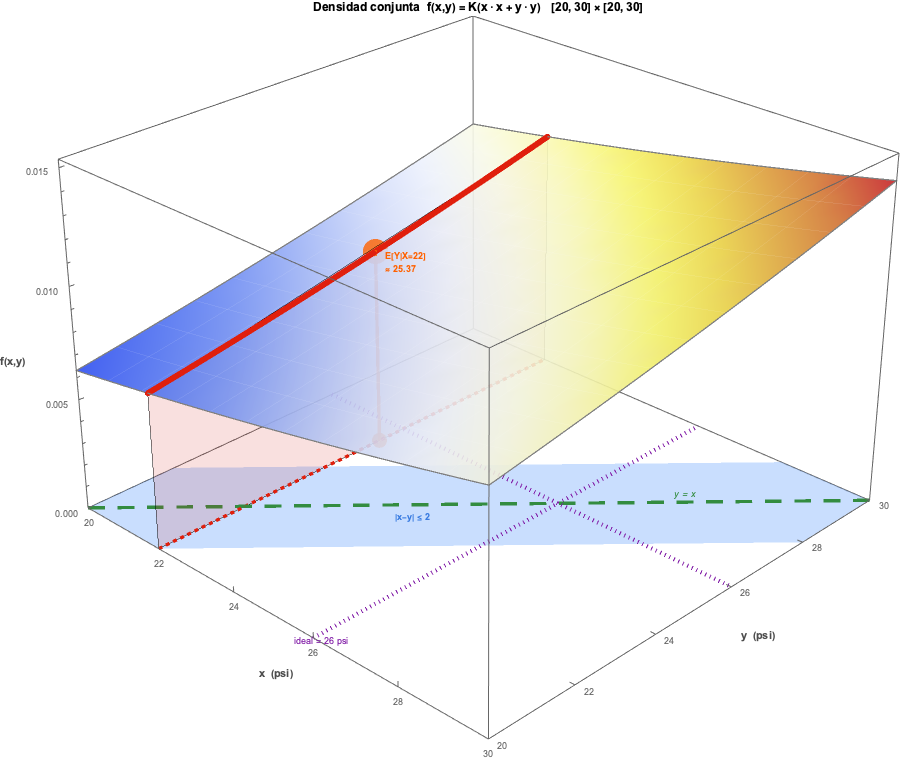

In [168]:
(* ============================================================
   Calibreme el aire — Visualización 3D de f(x,y) = K(x²+y²)
   Características resaltadas:
     · Superficie de densidad coloreada por intensidad
     · Banda |x-y| ≤ 2  (ítem c)  — proyectada en la base
     · Corte condicional en x = 22  (ítems g, h)
     · Punto E[Y|X=22] ≈ 25.37 sobre la superficie
     · Líneas de presión ideal x=26, y=26  (ítem b)
     · Diagonal y=x  (referencia de paridad)
   ============================================================ *)

K  = 3/380000;
f[x_, y_] := K*(x^2 + y^2);

EYcond = N[42525/1676];          (* E[Y|X=22] ≈ 25.37 *)
zLo    = f[20, 20];              (* densidad mínima en (20,20) *)
zHi    = f[30, 30];              (* densidad máxima en (30,30) *)
zMax   = zHi * 1.08;

(* ── 1. Superficie de densidad (coloreada: frío=baja, cálido=alta) ── *)
surf = Plot3D[f[x, y], {x, 20, 30}, {y, 20, 30},
  ColorFunction -> Function[{x, y, z},
    ColorData["TemperatureMap"][Rescale[z, {zLo, zHi}]]],
  ColorFunctionScaling -> False,
  Mesh          -> 10,
  MeshStyle     -> Directive[White, Opacity[0.18], Thin],
  PlotStyle     -> Opacity[0.90],
  BoundaryStyle -> Directive[GrayLevel[0.5], Thickness[0.0015]]
];

(* ── 2. Plano semitransparente en x = 22 ── *)
plano22 = Graphics3D[{
  Opacity[0.14], RGBColor[0.85, 0.15, 0.10],
  Polygon[{
    {22, 20, 0},      {22, 30, 0},
    {22, 30, f[22,30]}, {22, 20, f[22,20]}
  }]
}];

(* ── 3. Curva condicional f(22, y) trazada sobre la superficie ── *)
curvaCond = ParametricPlot3D[
  {22, y, f[22, y]}, {y, 20, 30},
  PlotStyle -> Directive[RGBColor[0.88, 0.12, 0.05], Thickness[0.007]]
];

(* ── 4. Proyección de la condicional en el plano z = 0 ── *)
proyBase = ParametricPlot3D[
  {22, y, 0}, {y, 20, 30},
  PlotStyle -> Directive[RGBColor[0.88, 0.12, 0.05], Dashed, Thickness[0.004]]
];

(* ── 5. Diagonal y = x en la base (paridad de presiones) ── *)
diagonal = ParametricPlot3D[
  {t, t, 0}, {t, 20, 30},
  PlotStyle -> Directive[RGBColor[0.20, 0.55, 0.25], Dashing[{0.02, 0.015}],
               Thickness[0.004]]
];

(* ── 6. Región |x-y| ≤ 2 proyectada en la base (ítem c) ── *)
banda = Graphics3D[{
  Opacity[0.28], RGBColor[0.22, 0.48, 0.88],
  EdgeForm[None],
  Polygon[{{20,20,0}, {22,20,0}, {22,24,0}, {20,22,0}}],   (* franja 1 *)
  Polygon[{{22,20,0}, {28,26,0}, {28,30,0}, {22,24,0}}],   (* franja 2 *)
  Polygon[{{28,26,0}, {30,28,0}, {30,30,0}, {28,30,0}}]    (* franja 3 *)
}];

(* ── 7. Líneas de presión ideal: x=26, y=26 (ítem b) ── *)
idealX = ParametricPlot3D[{26, t, 0}, {t, 20, 30},
  PlotStyle -> Directive[RGBColor[0.50, 0.10, 0.65], Dotted, Thickness[0.005]]];

idealY = ParametricPlot3D[{t, 26, 0}, {t, 20, 30},
  PlotStyle -> Directive[RGBColor[0.50, 0.10, 0.65], Dotted, Thickness[0.005]]];

(* ── 8. Punto E[Y|X=22] sobre la superficie y su plomada ── *)
puntoEY = Graphics3D[{
  (* Plomada vertical *)
  RGBColor[1.0, 0.38, 0.0], Opacity[0.80], Thickness[0.004],
  Line[{{22, EYcond, 0}, {22, EYcond, f[22, EYcond]}}],
  (* Punto sobre la superficie *)
  PointSize[0.030], Point[{22, EYcond, f[22, EYcond]}],
  (* Punto en la base *)
  PointSize[0.018], Point[{22, EYcond, 0}]
}];

(* ── 9. Etiquetas 3D ── *)
etiquetas = Graphics3D[{
  (* Eje condicional *)
  Text[Style["x = 22", 10, Bold, RGBColor[0.88,0.12,0.05]],
       {22, 19.0, f[22,30]*0.55}],
  (* E[Y|X=22] *)
  Text[Style["E[Y|X=22]\n≈ 25.37", 9, Bold, RGBColor[1.0,0.38,0.0]],
       {22.8, EYcond, f[22, EYcond] + 0.000012}],
  (* Diagonal *)
  Text[Style["y = x", 9, Italic, RGBColor[0.20,0.55,0.25]],
       {27.5, 27.8, 0.000010}],
  (* Presión ideal *)
  Text[Style["ideal = 26 psi", 9, RGBColor[0.50,0.10,0.65]],
       {26.2, 20.0, 0.000008}],
  (* Banda *)
  Text[Style["|x-y| ≤ 2", 9, Bold, RGBColor[0.22,0.48,0.88]],
       {24.5, 23.8, 0.000008}]
}];

(* ── Ensamble final ── *)
Show[
  surf, plano22, curvaCond, proyBase,
  diagonal, banda, idealX, idealY,
  puntoEY, etiquetas,

  ViewPoint   -> {2.6, -2.7, 1.9},
  ViewVertical -> {0, 0, 1},
  BoxRatios   -> {1, 1, 0.68},
  PlotRange   -> {{20, 30}, {20, 30}, {0, zMax}},
  PlotRangePadding -> 0,

  Axes      -> True,
  AxesLabel -> {
    Style["x  (psi)", 11, Bold, GrayLevel[0.3]],
    Style["y  (psi)", 11, Bold, GrayLevel[0.3]],
    Style["f(x,y)",   11, Bold, GrayLevel[0.3]]
  },
  Ticks -> {Range[20, 30, 2], Range[20, 30, 2], Automatic},
  AxesStyle -> Directive[GrayLevel[0.4], 9],

  PlotLabel -> Style[
    "Densidad conjunta  f(x,y) = K(x\[ThinSpace]\[CenterDot]\[ThinSpace]x + y\[ThinSpace]\[CenterDot]\[ThinSpace]y)   [20, 30] \[Times] [20, 30]",
    12, Bold, Black
  ],

  ImageSize -> 900,
  Background -> White
]


El script genera un gráfico 3D que reúne en una sola vista las características más importantes del problema. Cada capa visual corresponde a un ítem:

| Elemento visual | Color | Ítem |
|---|---|---|
| Superficie de densidad | Degradado frío→cálido | — |
| Banda $\|x-y\|\leq 2$ en la base | Azul translúcido | (c) |
| Plano y curva condicional $x=22$ | Rojo | (g), (h) |
| Punto $E[Y\|X=22]\approx 25.37$ con plomada | Naranja | (h) |
| Líneas de presión ideal $x=y=26$ | Morado punteado | (b) |
| Diagonal $y=x$ | Verde | referencia |

Lo más llamativo que el gráfico revela de inmediato es que la densidad **no es plana**: crece marcadamente hacia la esquina $(30,30)$ —ambas llantas sobreinfladas— y es mínima cerca de $(20,20)$. Esto significa que la combinación de presiones bajas simultáneas es el evento menos probable, mientras que presiones altas en ambas llantas son los valores más frecuentes según este modelo.